# 00. 데이터 소개: 가상 주간 셀아웃 데이터

이 프로젝트의 목표는 **"이번 주 셀아웃(판매량)에 어떤 요인이 얼마나 영향을 줬는가"**를 설명하는 모델을 만드는 것입니다.

실제 데이터가 준비되기 전이라, **정답 효과를 미리 정해두고 만든 가상 데이터**(2년, 104주)를 사용합니다.
정답을 알고 있기 때문에, 각 모델이 효과를 얼마나 정확히 찾아내는지 채점할 수 있다는 장점이 있습니다.

> 실제 데이터로 바꿀 때는 `src/common.py`의 `load_data()`만 수정하면 모든 노트북이 그대로 동작합니다.

In [1]:
import sys, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib  # 한글 글꼴
from common import *
plt.rcParams["figure.dpi"] = 110
df = load_data()
y = df.sellout.values.astype(float)
print(df.shape)

(104, 8)


## 컬럼 설명

| 컬럼 | 의미 | 단위 |
|---|---|---|
| `week` | 주 시작일(월요일) | 날짜 |
| `sellout` | 그 주의 판매량 (설명하려는 대상) | 개 |
| `discount_pct` | 할인율 | % |
| `promo` | 프로모션(매대 진열, 1+1, 기획전 등) 진행 여부 | 0/1 |
| `ad_spend` | 광고비 | 백만원 |
| `holiday` | 공휴일·연휴가 낀 주 | 0/1 |
| `temp` | 주 평균기온 | °C |
| `stockout_days` | 재고가 떨어져 못 판 날 수 | 일 |

In [2]:
df.head(10)

,week,sellout,discount_pct,promo,ad_spend,holiday,temp,stockout_days
0,2024-10-07,966.0,0,0,20.7,0,4.0,0
1,2024-10-14,982.0,0,0,0.0,0,1.3,0
2,2024-10-21,989.0,0,0,14.9,0,4.8,0
3,2024-10-28,1424.0,10,1,24.8,0,7.0,0
4,2024-11-04,1002.0,0,0,26.8,0,-0.1,0
5,2024-11-11,1157.0,0,0,9.5,0,0.6,0
6,2024-11-18,1235.0,10,0,0.0,0,1.2,0
7,2024-11-25,1321.0,0,1,7.8,0,0.2,1
8,2024-12-02,1225.0,0,0,29.5,0,4.0,0
9,2024-12-09,1139.0,0,0,0.0,0,1.3,0


In [3]:
df.describe().round(1)

,week,sellout,discount_pct,promo,ad_spend,holiday,temp,stockout_days
count,104,104.0,104.0,104.0,104.0,104.0,104.0,104.0
mean,2025-10-02 12:00:00,1208.2,4.2,0.2,9.3,0.1,13.2,0.2
min,2024-10-07 00:00:00,700.0,0.0,0.0,0.0,0.0,-0.1,0.0
25%,2025-04-05 06:00:00,1075.0,0.0,0.0,0.0,0.0,5.9,0.0
50%,2025-10-02 12:00:00,1189.5,0.0,0.0,0.0,0.0,13.6,0.0
75%,2026-03-31 18:00:00,1311.0,10.0,0.0,19.5,0.0,20.6,0.0
max,2026-09-28 00:00:00,1878.0,20.0,1.0,29.5,1.0,28.5,4.0
std,NaN,208.5,7.0,0.4,10.8,0.3,8.0,0.8


## 판매량과 요인들의 흐름

판매량은 1년 주기로 오르내리고(계절성), 전체적으로 조금씩 늘어납니다(추세).
프로모션·광고·공휴일이 있는 주에 판매가 튀는 모습을 볼 수 있습니다.

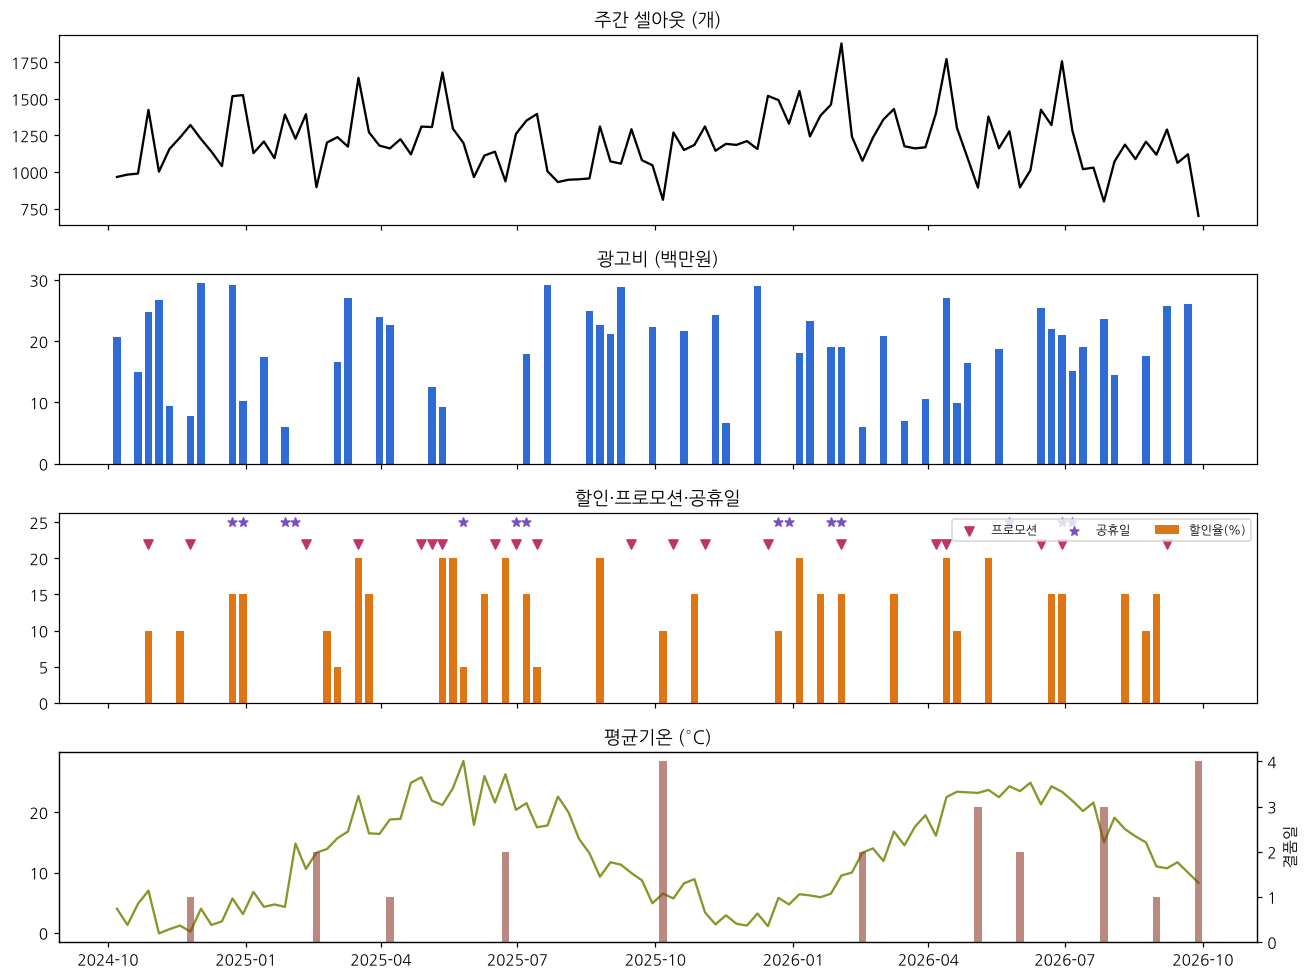

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(df.week, df.sellout, color="black"); axes[0].set_title("주간 셀아웃 (개)")
axes[1].bar(df.week, df.ad_spend, width=5, color=FACTOR_COLORS["광고"]); axes[1].set_title("광고비 (백만원)")
axes[2].bar(df.week, df.discount_pct, width=5, color=FACTOR_COLORS["할인"], label="할인율(%)")
axes[2].scatter(df.week[df.promo == 1], [22] * df.promo.sum(), color=FACTOR_COLORS["프로모션"], marker="v", label="프로모션")
axes[2].scatter(df.week[df.holiday == 1], [25] * df.holiday.sum(), color=FACTOR_COLORS["공휴일"], marker="*", label="공휴일")
axes[2].legend(ncol=3, fontsize=8); axes[2].set_title("할인·프로모션·공휴일")
axes[3].plot(df.week, df.temp, color=FACTOR_COLORS["기온"]); axes[3].set_title("평균기온 (°C)")
ax2 = axes[3].twinx(); ax2.bar(df.week, df.stockout_days, width=5, color=FACTOR_COLORS["결품"], alpha=.6); ax2.set_ylabel("결품일")
plt.tight_layout()

## 정답 효과 (가상 데이터를 만든 규칙)

```
셀아웃 = 900 + 1.5·t                       ← 기본 수요 (출발점 + 추세)
       + 120·sin(2π(t−8)/52)               ← 계절성
       + 14 × 할인율
       + 260 × 프로모션
       + 45 × ln(1 + 광고스톡)               ← 광고 (이월률 50%, 포화)
       + 180 × 공휴일
       − 6 × (기온 − 14)
       − 95 × 결품일수
       + 노이즈 (표준편차 45)
```

실제 데이터에서는 이 정답을 알 수 없습니다. 여기서는 모델을 채점하는 용도로만 씁니다.

In [5]:
truth = true_contrib(df)
pd.Series(effects(truth, df)).round(1).rename("정답 효과").to_frame()

,정답 효과
할인,14.0
프로모션,260.0
광고,52.9
공휴일,180.0
기온,-6.0
결품,-95.0
계절성,120.0


### 효과 크기의 공통 정의

모델마다 효과를 표현하는 방식이 달라서(계수, 곡선, SHAP 값…), 모든 모델에 **같은 정의**를 적용해 비교합니다.

- **할인·기온·결품**: 요인 값이 1 늘 때 기여도가 얼마나 변하나 (기울기)
- **프로모션·공휴일·광고**: 해당 주와 아닌 주의 평균 기여도 차이
- **계절성**: 성수기~비수기 폭의 절반

## 요인끼리의 상관관계

요인끼리 같이 움직이면 모델이 효과를 나누기 어렵습니다. 특히 **기온은 계절과 함께 움직인다**는 점을 기억해 두세요. 이후 GAM과 트리 모델에서 이 문제가 드러납니다.

In [6]:
t = np.arange(len(df))
season = np.sin(2 * np.pi * (t - 8) / 52)
X = df[["discount_pct", "promo", "ad_spend", "holiday", "temp", "stockout_days"]].assign(계절패턴=season)
X.corr().round(2).style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)

,discount_pct,promo,ad_spend,holiday,temp,stockout_days,계절패턴
discount_pct,1.000000,0.070000,-0.020000,0.120000,0.200000,-0.020000,0.080000
promo,0.070000,1.000000,-0.030000,0.020000,0.080000,-0.120000,0.000000
ad_spend,-0.020000,-0.030000,1.000000,0.020000,-0.110000,-0.140000,-0.130000
holiday,0.120000,0.020000,0.020000,1.000000,0.030000,-0.120000,0.130000
temp,0.200000,0.080000,-0.110000,0.030000,1.000000,0.040000,0.100000
stockout_days,-0.020000,-0.120000,-0.140000,-0.120000,0.040000,1.000000,-0.090000
계절패턴,0.080000,0.000000,-0.130000,0.130000,0.100000,-0.090000,1.000000
